# [Kaggle] Skip-Connection CAE Training - All Categories

Trains a Skip-Connection Convolutional Autoencoder for MVTec AD using a Kaggle GPU.
This notebook is designed to be run on Kaggle, utilizing `/kaggle/input/` and writing results to `/kaggle/working/`.

### Kaggle Setup Instructions:
1. Requires **Internet: ON** (to download packages if needed).
2. Requires **GPU: ON** (P100, T4x2, etc.).
3. Add the **MVTec AD** dataset (search "mvtec ad" in Add Data).
4. Upload your project source code (`src/` folder) as a dataset, OR clone it from a repo, OR copy the required code cells if you haven't uploaded it.

In [2]:
# ==============================================================================
# UNIFIED KAGGLE SETUP & IMPORTS
# ==============================================================================
import os
import sys
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
import pandas as pd
import time
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Exact paths we discovered earlier
KAGGLE_WORKING = '/kaggle/working'
MVTEC_PATH = '/kaggle/input/datasets/ipythonx/mvtec-ad'
SRC_PREFIX = '/kaggle/input/datasets/mohammadhameem/thesis-project-source-code'

# 2. Add source to path so we can import from 'src'
sys.path.insert(0, SRC_PREFIX)

# 3. Standard MVTec categories
MVTEC_CATEGORIES = [
    'bottle', 'cable', 'capsule', 'carpet', 'grid', 
    'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 
    'tile', 'toothbrush', 'transistor', 'wood', 'zipper'
]

# 4. Import our local project files & patch config
try:
    from src import config as proj_cfg
    proj_cfg.DATA_DIR = Path(MVTEC_PATH).parent
    proj_cfg.MVTEC_DIR = Path(MVTEC_PATH)
    
    from src.data import create_mvtec_dataloaders
    from src.data.transforms import denormalize
    from src.models.skip_cae import create_skip_cae
    from src.training import get_optimizer, get_scheduler, EarlyStopping
    print("✅ MVTec paths and source code loaded successfully!")
except ImportError as e:
    print(f"❌ ERROR IMPORTING SOURCE CODE: {e}")

# 5. Device Setup
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Using device: {DEVICE}")

# 6. Create Output Dirs
MODELS_DIR = Path(KAGGLE_WORKING) / 'models'
FIGURES_DIR = Path(KAGGLE_WORKING) / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


✅ MVTec paths and source code loaded successfully!
✅ Using device: cuda


In [3]:
import os
print("Exploring /kaggle/input ...")
for root, dirs, files in os.walk("/kaggle/input"):
    # Only print up to a certain depth to keep it readable
    if root.count(os.sep) <= 4: 
        print(f"\n📂 {root}")
        for d in dirs:
            print(f"   📁 {d}")
        # if it contains python files, it's our source code
        if any(f.endswith('.py') for f in files):
            print(f"   🐍 [Contains Python files]")


Exploring /kaggle/input ...

📂 /kaggle/input
   📁 datasets

📂 /kaggle/input/datasets
   📁 ipythonx
   📁 mohammadhameem

📂 /kaggle/input/datasets/ipythonx
   📁 mvtec-ad

📂 /kaggle/input/datasets/mohammadhameem
   📁 thesis-project-source-code


In [4]:
# ---------------------------------------------------------
# Kaggle Environment Setup
# ---------------------------------------------------------
import os
import sys

KAGGLE_INPUT = '/kaggle/input'
KAGGLE_WORKING = '/kaggle/working'

# 1. Update these to the EXACT paths we just found:
MVTEC_PATH = '/kaggle/input/datasets/ipythonx/mvtec-ad'
SRC_PREFIX = '/kaggle/input/datasets/mohammadhameem/thesis-project-source-code'

# 2. Add source code to path
if os.path.exists(SRC_PREFIX):
    # This allows 'from src import x' to work
    sys.path.insert(0, SRC_PREFIX)
    print(f"Source code loaded from {SRC_PREFIX}")
else:
    print(f"WARNING: Source code folder not found at {SRC_PREFIX}.")


Source code loaded from /kaggle/input/datasets/mohammadhameem/thesis-project-source-code


## Environment Patching

Since we are running on Kaggle, we might need to patch the config to point to the correct data paths.

In [5]:
# It's possible the imported config points to F:/Thesis.
# Let's temporarily patch it to use Kaggle paths if we successfully imported the source code.
try:
    from src import config as proj_cfg
    proj_cfg.DATA_DIR = Path(MVTEC_PATH).parent # usually data structure expects DATA_DIR / 'mvtec_anomaly_detection'
    proj_cfg.MVTEC_DIR = Path(MVTEC_PATH)
    print(f"Patched config paths. MVTEC_DIR is now: {proj_cfg.MVTEC_DIR}")
    
    from src.data import create_mvtec_dataloaders
    from src.data.transforms import denormalize
    from src.models.skip_cae import create_skip_cae
    from src.training import get_optimizer, get_scheduler, EarlyStopping
    
    # Standard MVTec categories list if not imported
    MVTEC_CATEGORIES = [
        'bottle', 'cable', 'capsule', 'carpet', 'grid', 
        'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 
        'tile', 'toothbrush', 'transistor', 'wood', 'zipper'
    ]
    print("Successfully imported project modules.")
except ImportError as e:
    print(f"Import Error: {e}")
    print("CRITICAL: Could not import source code. Make sure you uploaded the 'src' folder as a dataset.")


Patched config paths. MVTEC_DIR is now: /kaggle/input/datasets/ipythonx/mvtec-ad
Successfully imported project modules.


## Configuration

In [6]:
# Standard MVTec categories list - Define it outside the try block so it always exists
MVTEC_CATEGORIES = [
    'bottle', 'cable', 'capsule', 'carpet', 'grid', 
    'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 
    'tile', 'toothbrush', 'transistor', 'wood', 'zipper'
]

try:
    from src import config as proj_cfg
    proj_cfg.DATA_DIR = Path(MVTEC_PATH).parent
    proj_cfg.MVTEC_DIR = Path(MVTEC_PATH)
    
    from src.data import create_mvtec_dataloaders
    from src.data.transforms import denormalize
    from src.models.skip_cae import create_skip_cae
    from src.training import get_optimizer, get_scheduler, EarlyStopping
    
    print("Modules imported and config patched successfully.")
except ImportError as e:
    print(f"CRITICAL ERROR - Code Import Failed: {e}")
    print(f"Check if {SRC_PREFIX} actually exists!")


Modules imported and config patched successfully.


## Visualization Helpers

In [7]:
def save_and_show(fig, path):
    fig.savefig(path, dpi=150, bbox_inches='tight')
    # Note: On Kaggle we usually want to draw the plot so it appears in the notebook output cell
    plt.show() 
    plt.close(fig)
    print(f"  Saved: {path}")

def plot_loss_curve(history, category, save_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(f'Skip-CAE Training Loss — {category}', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    save_and_show(fig, save_path)

def plot_roc_curve(all_scores, all_labels, auc_val, category, save_path):
    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Skip-CAE (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {category}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    save_and_show(fig, save_path)

## Training Function

In [8]:
def train_skip_cae_category(category):
    print(f"\n{'='*60}")
    print(f"Training Skip-CAE: {category.upper()}")
    print(f"{'='*60}")

    try:
        train_loader, test_loader = create_mvtec_dataloaders(
            category, batch_size=CONFIG['batch_size'], return_mask=True
        )
    except Exception as e:
        print(f"Skipping {category}: Data loading failed. Error: {e}")
        return None

    model = create_skip_cae().to(DEVICE)
    optimizer = get_optimizer(model, lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
    scheduler = get_scheduler(optimizer, patience=2, factor=0.5)
    early_stopping = EarlyStopping(patience=CONFIG['patience'], mode='min')
    criterion = nn.MSELoss()

    history = {'train_loss': []}
    start_time = time.time()

    for epoch in range(1, CONFIG['num_epochs'] + 1):
        model.train()
        epoch_loss = 0.0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{CONFIG['num_epochs']} [{category}]', leave=False):
            images = batch[0].to(DEVICE)
            optimizer.zero_grad()
            reconstruction = model(images)
            loss = criterion(reconstruction, images)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        scheduler.step(avg_loss)

        if early_stopping(avg_loss):
            print(f"Early stopping triggered at epoch {epoch}. Loss: {avg_loss:.5f}")
            break

    train_time = time.time() - start_time
    print(f"  Training finished in {train_time:.1f}s")

    # Evaluate
    model.eval()
    all_scores, all_labels = [], []
    print("  Evaluating on test set...")
    with torch.no_grad():
        for img, mask, label in test_loader:
            img = img.to(DEVICE)
            scores = model.get_anomaly_score(img)
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(label.numpy())

    try:
        auc = roc_auc_score(all_labels, all_scores)
        print(f"  >>> {category.upper()} ROC-AUC: {auc:.4f} <<<")
    except:
        auc = 0.0

    # Save model
    save_path = MODELS_DIR / f'skip_cae_{category}_final.pth'
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': CONFIG,
        'history': history,
        'auc': auc,
    }, save_path)
    print(f"  Model saved.")

    # Plots
    plot_loss_curve(history, category, FIGURES_DIR / f'skip_cae_{category}_loss.png')
    if auc > 0:
        plot_roc_curve(all_scores, all_labels, auc, category, FIGURES_DIR / f'skip_cae_{category}_roc.png')

    return {
        'category': category,
        'auc': auc,
        'epochs': len(history['train_loss']),
        'train_time_s': round(train_time, 1)
    }

## Execute Run

In [9]:
results = []
total_start = time.time()

# 1. Define configuration right here to ensure it's always loaded!
CONFIG = {
    'batch_size': 32,
    'num_epochs': 50,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    'patience': 5,
}
CATEGORIES_TO_TRAIN = MVTEC_CATEGORIES
print(f"Will train {len(CATEGORIES_TO_TRAIN)} categories.")

# 2. Run the loop
for cat in CATEGORIES_TO_TRAIN:
    # Important on Kaggle: Clear cache to prevent OOM errors across categories
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
        
    res = train_skip_cae_category(cat)
    if res:
        results.append(res)
        
total_elapsed = time.time() - total_start
print(f"\n{'='*60}")
print(f"ALL CATEGORIES COMPLETE in {total_elapsed/60:.1f} minutes")
print(f"{'='*60}")


Will train 15 categories.

Training Skip-CAE: BOTTLE


  Training finished in 554.3s
  Evaluating on test set...
  >>> BOTTLE ROC-AUC: 0.4405 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_bottle_loss.png
  Saved: /kaggle/working/figures/skip_cae_bottle_roc.png

Training Skip-CAE: CABLE


  Training finished in 806.7s
  Evaluating on test set...
  >>> CABLE ROC-AUC: 0.4856 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_cable_loss.png
  Saved: /kaggle/working/figures/skip_cae_cable_roc.png

Training Skip-CAE: CAPSULE


Early stopping triggered at epoch 40. Loss: 0.00132
  Training finished in 627.8s
  Evaluating on test set...
  >>> CAPSULE ROC-AUC: 0.4280 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_capsule_loss.png
  Saved: /kaggle/working/figures/skip_cae_capsule_roc.png

Training Skip-CAE: CARPET


Early stopping triggered at epoch 35. Loss: 0.00192
  Training finished in 691.3s
  Evaluating on test set...
  >>> CARPET ROC-AUC: 0.5132 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_carpet_loss.png
  Saved: /kaggle/working/figures/skip_cae_carpet_roc.png

Training Skip-CAE: GRID


...

Early stopping triggered at epoch 35. Loss: 0.00275
  Training finished in 464.4s
  Evaluating on test set...
  >>> TILE ROC-AUC: 0.8629 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_tile_loss.png
  Saved: /kaggle/working/figures/skip_cae_tile_roc.png

Training Skip-CAE: TOOTHBRUSH


  Training finished in 211.3s
  Evaluating on test set...
  >>> TOOTHBRUSH ROC-AUC: 0.6361 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_toothbrush_loss.png
  Saved: /kaggle/working/figures/skip_cae_toothbrush_roc.png

Training Skip-CAE: TRANSISTOR


  Training finished in 780.1s
  Evaluating on test set...
  >>> TRANSISTOR ROC-AUC: 0.5733 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_transistor_loss.png
  Saved: /kaggle/working/figures/skip_cae_transistor_roc.png

Training Skip-CAE: WOOD


Early stopping triggered at epoch 31. Loss: 0.00215
  Training finished in 540.0s
  Evaluating on test set...
  >>> WOOD ROC-AUC: 0.9596 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_wood_loss.png
  Saved: /kaggle/working/figures/skip_cae_wood_roc.png

Training Skip-CAE: ZIPPER


Early stopping triggered at epoch 48. Loss: 0.00101
  Training finished in 522.4s
  Evaluating on test set...
  >>> ZIPPER ROC-AUC: 0.5880 <<<
  Model saved.
  Saved: /kaggle/working/figures/skip_cae_zipper_loss.png
  Saved: /kaggle/working/figures/skip_cae_zipper_roc.png

ALL CATEGORIES COMPLETE in 147.1 minutes


## Summary Report

In [10]:
if results:
    df = pd.DataFrame(results)
    # Save CSV
    csv_path = Path(KAGGLE_WORKING) / 'skip_cae_results_all.csv'
    df.to_csv(csv_path, index=False)
    
    print("\n" + "="*40)
    print("RESULTS SUMMARY")
    print("="*40)
    print(df.sort_values('auc', ascending=False).to_string(index=False))
    print(f"\nMean AUC: {df['auc'].mean():.4f}")
else:
    print("No successful runs.")


RESULTS SUMMARY
  category      auc  epochs  train_time_s
      wood 0.959649      31         540.0
      tile 0.862915      35         464.4
      pill 0.839880      49         707.0
  hazelnut 0.790000      32         868.9
   leather 0.759511      45         696.0
toothbrush 0.636111      50         211.3
      grid 0.613200      23         284.1
    zipper 0.587973      48         522.4
transistor 0.573333      50         780.1
    carpet 0.513242      35         691.3
     cable 0.485570      50         806.7
    bottle 0.440476      50         554.3
   capsule 0.428002      40         627.8
 metal_nut 0.421799      50         510.3
     screw 0.000820      29         437.3

Mean AUC: 0.5942


Found 30 images. Displaying now...

🖼️ skip_cae_bottle_loss.png


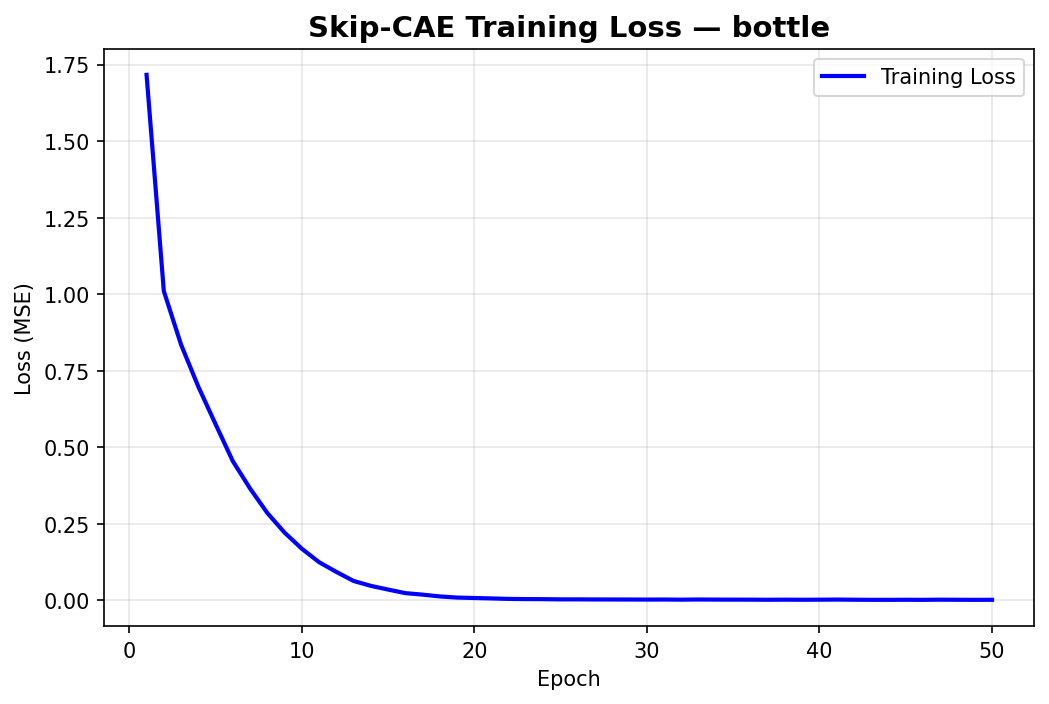



🖼️ skip_cae_bottle_roc.png


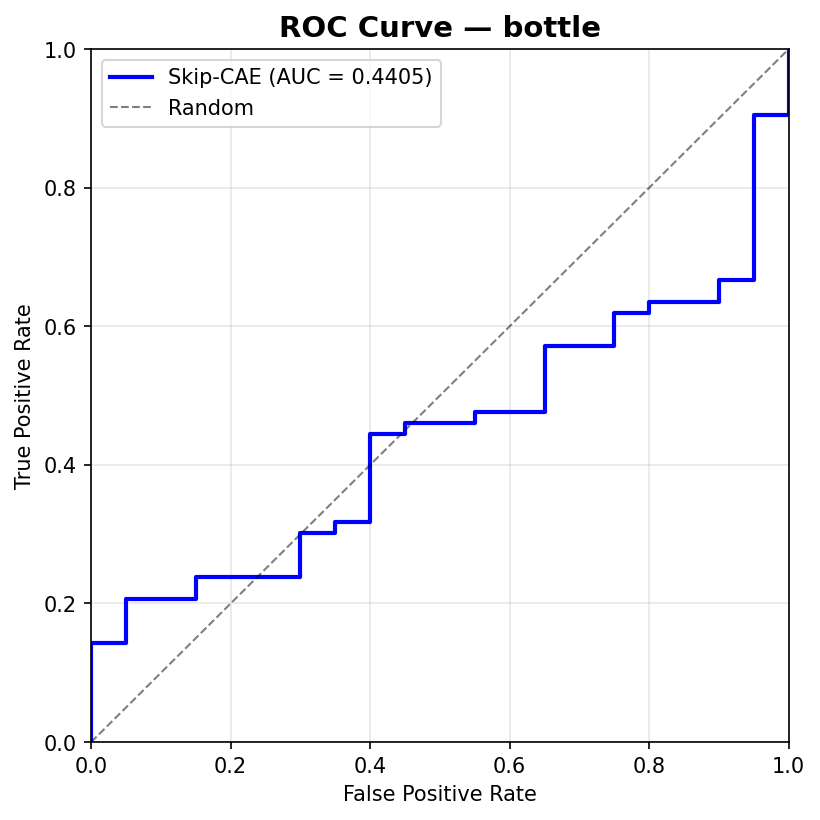



🖼️ skip_cae_cable_loss.png


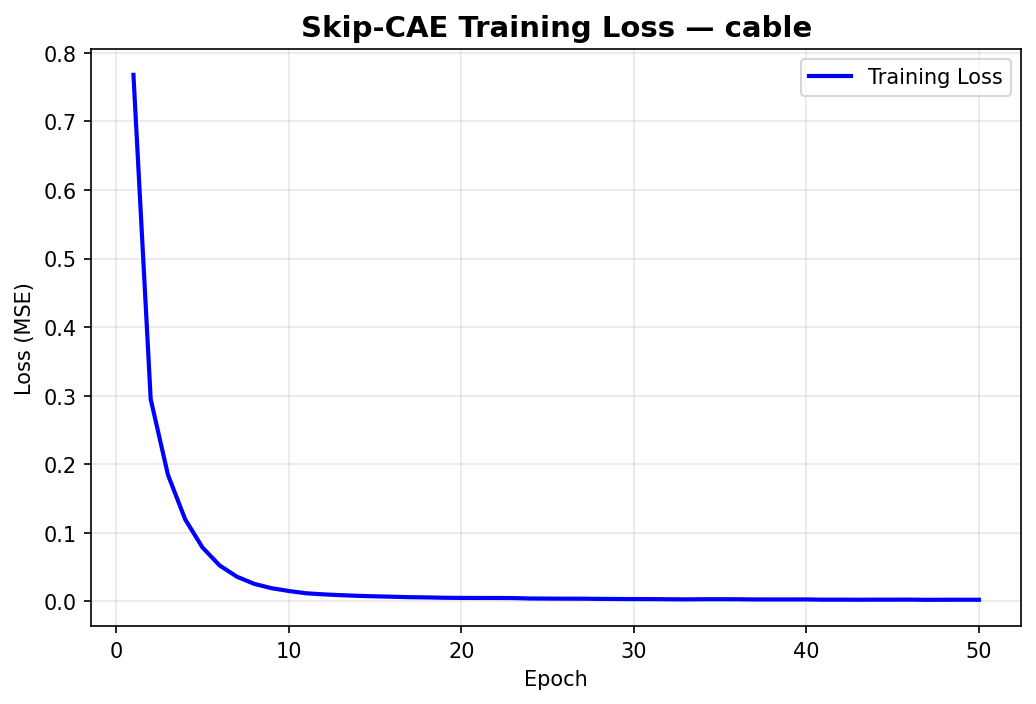



🖼️ skip_cae_cable_roc.png


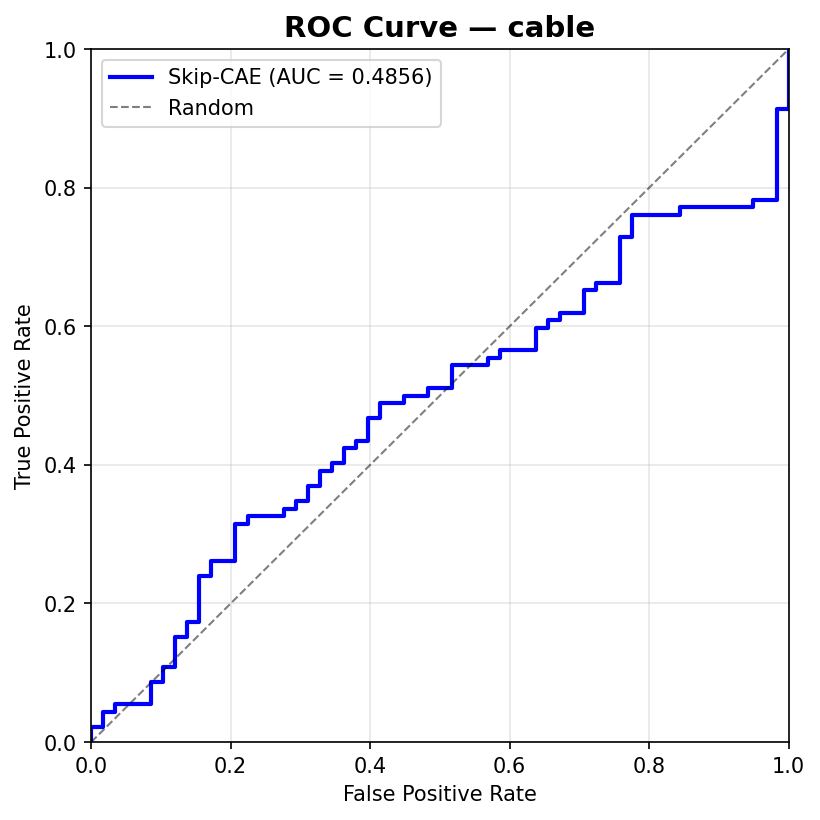



🖼️ skip_cae_capsule_loss.png


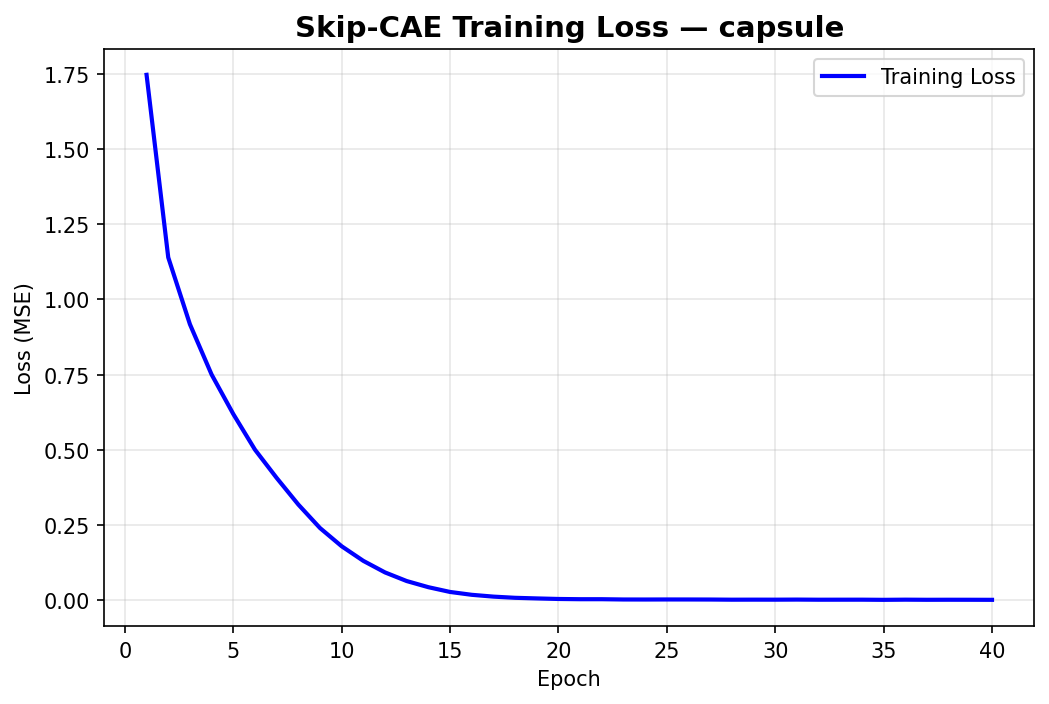



🖼️ skip_cae_capsule_roc.png


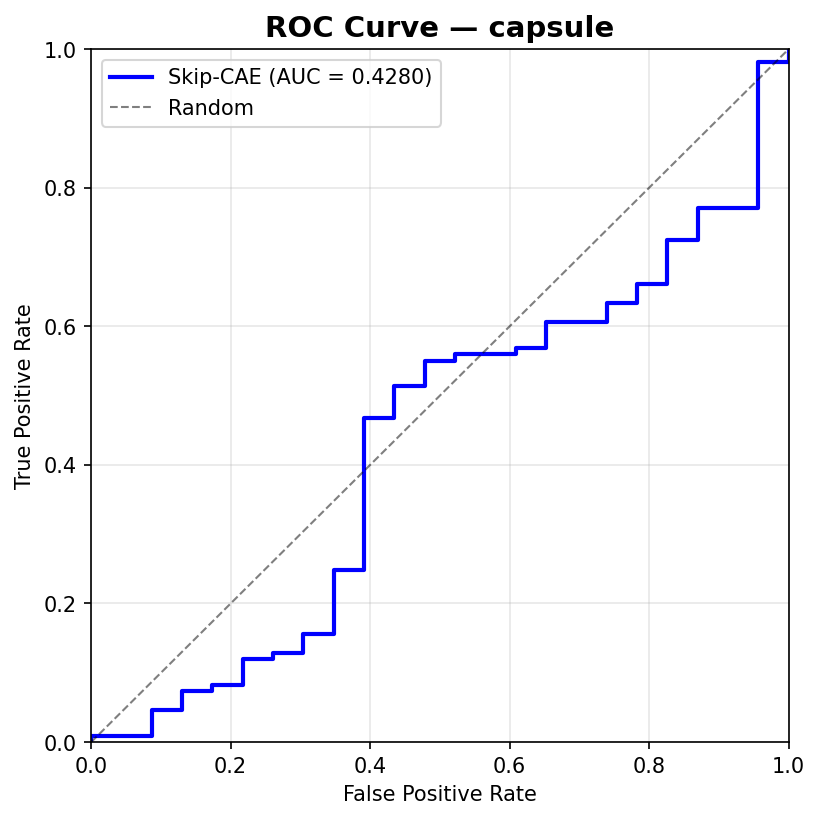



🖼️ skip_cae_carpet_loss.png


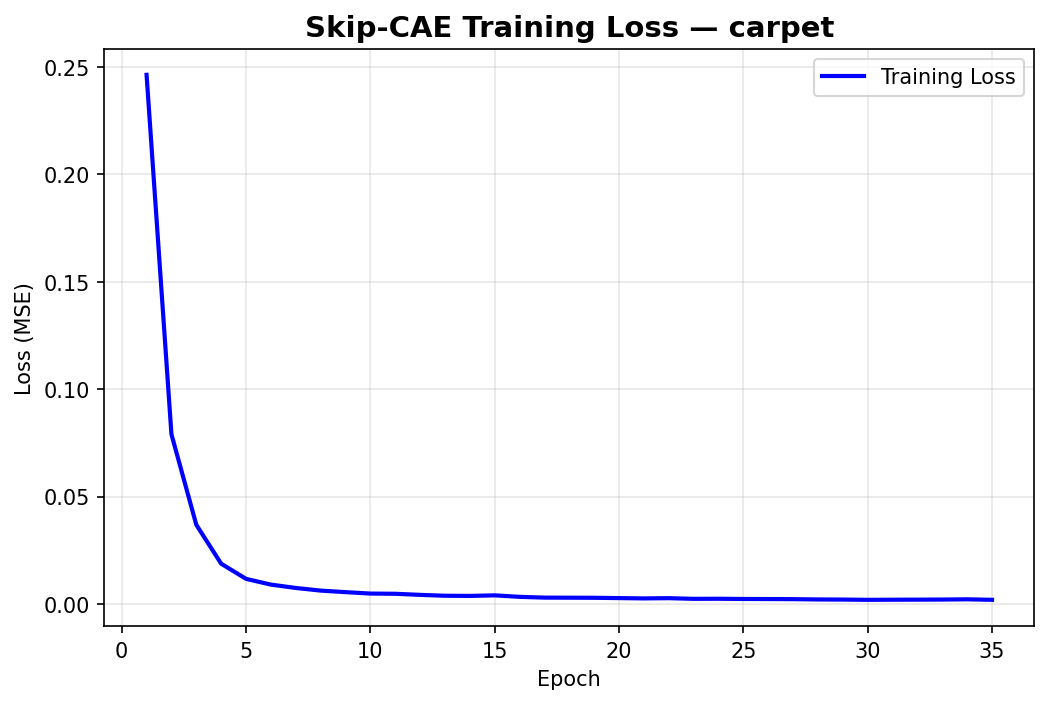



🖼️ skip_cae_carpet_roc.png


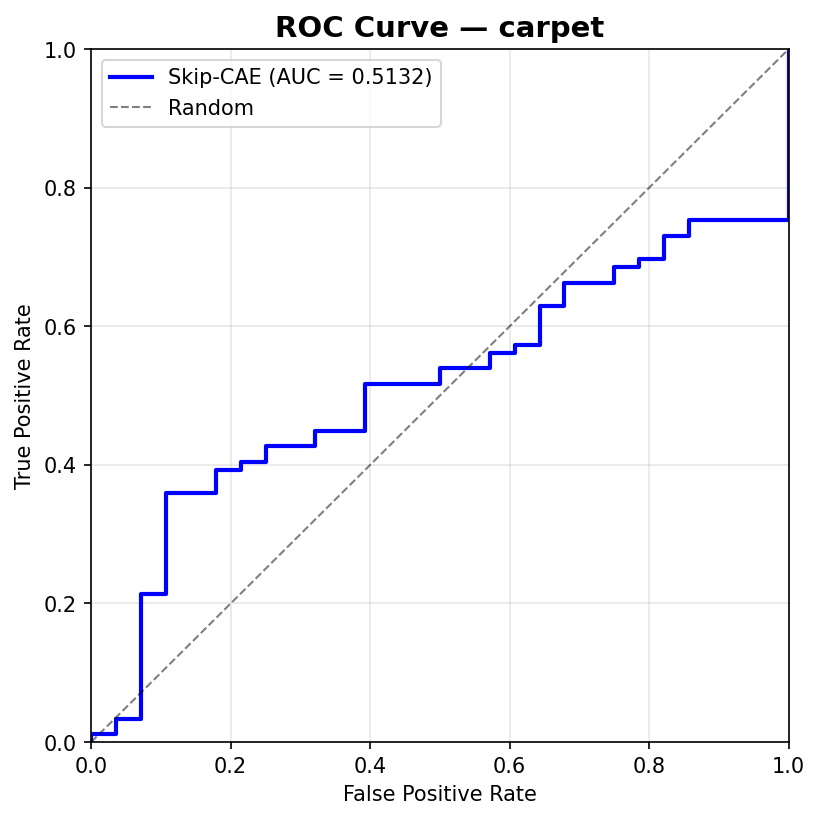



🖼️ skip_cae_grid_loss.png


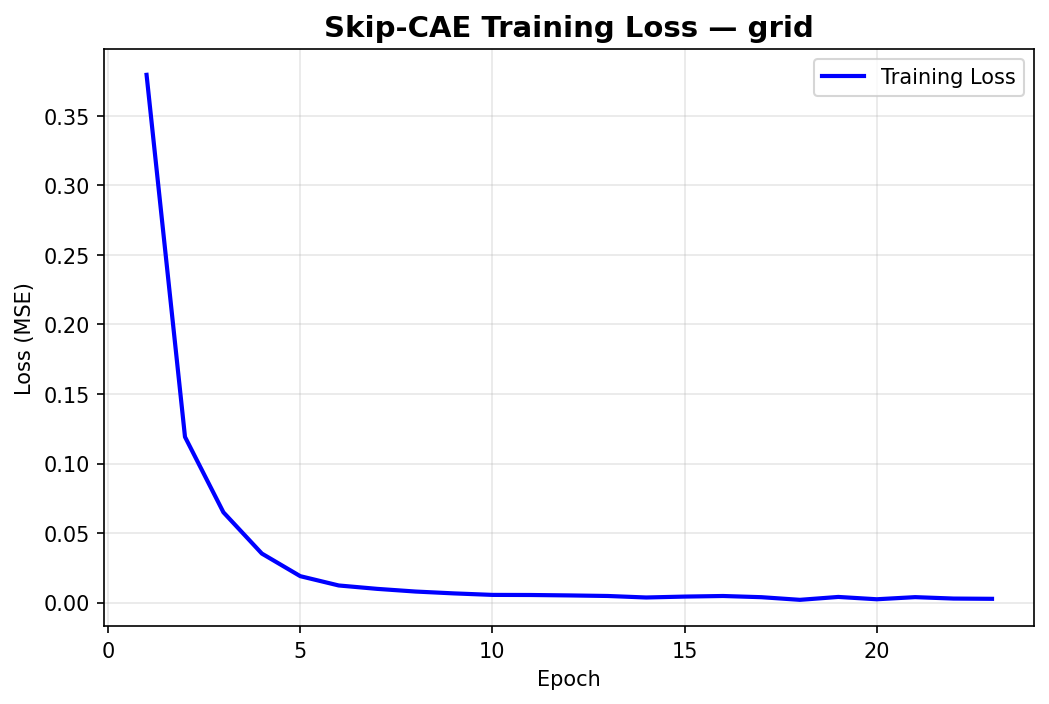



🖼️ skip_cae_grid_roc.png


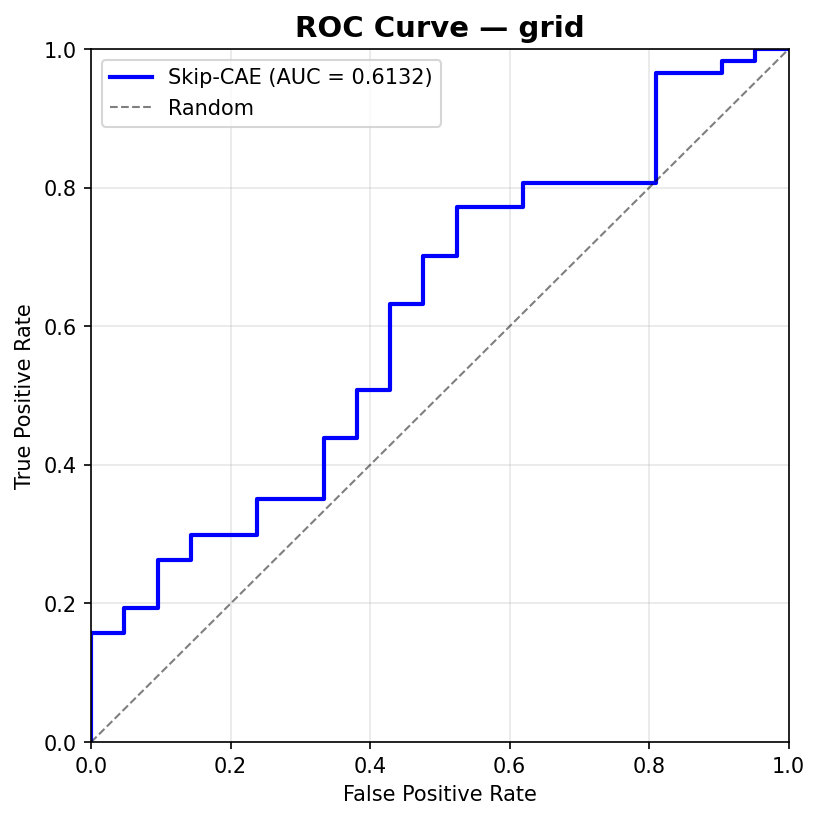



🖼️ skip_cae_hazelnut_loss.png


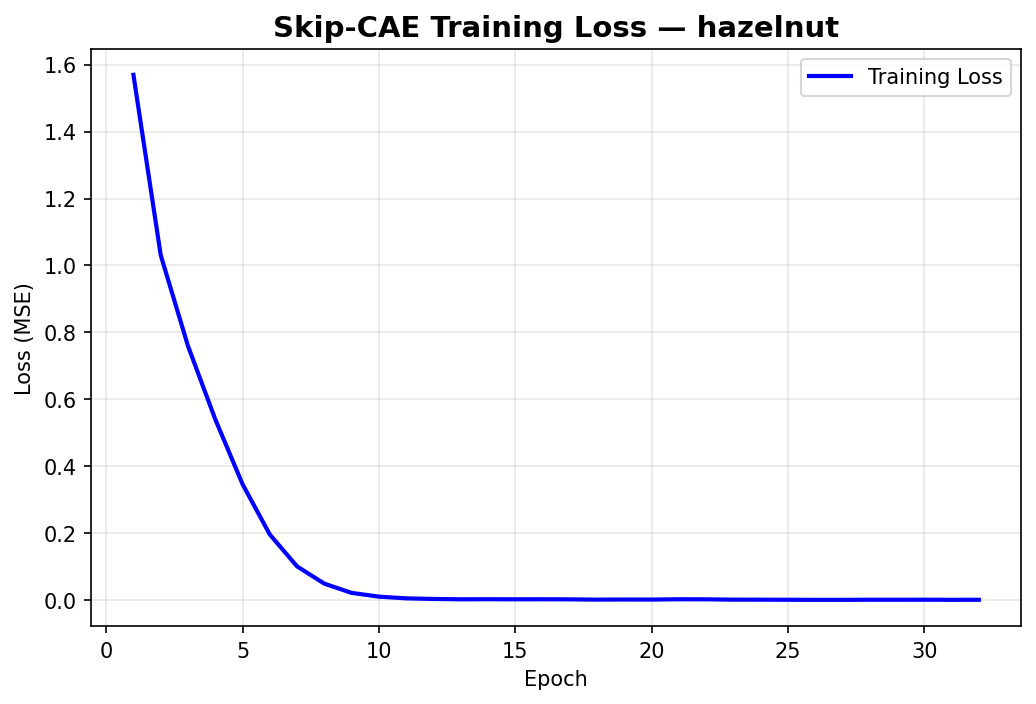



🖼️ skip_cae_hazelnut_roc.png


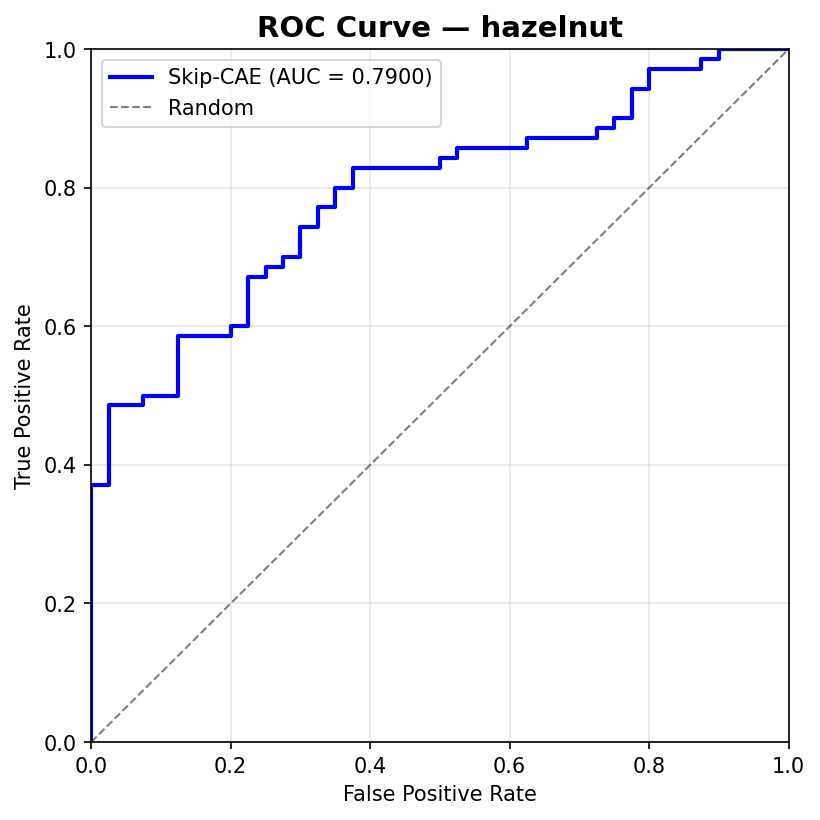



🖼️ skip_cae_leather_loss.png


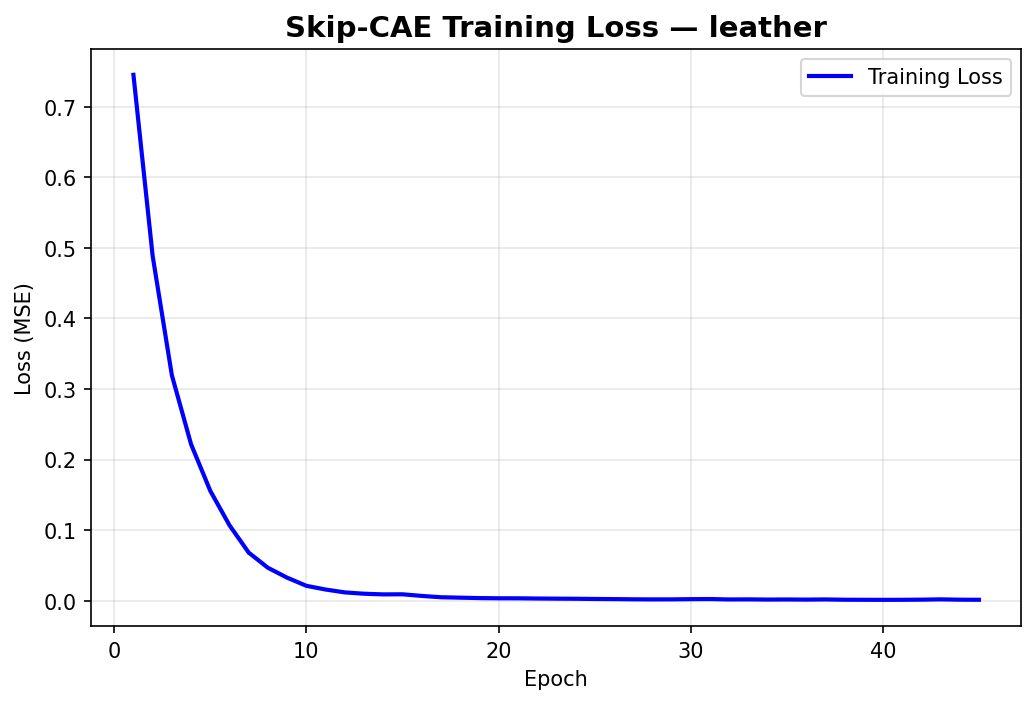



🖼️ skip_cae_leather_roc.png


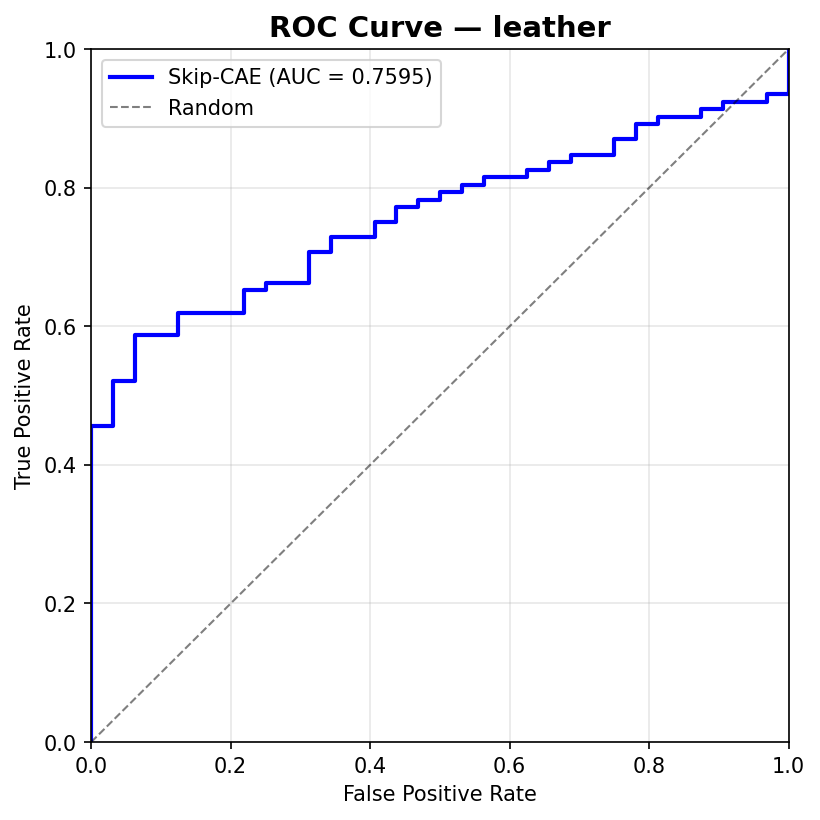



🖼️ skip_cae_metal_nut_loss.png


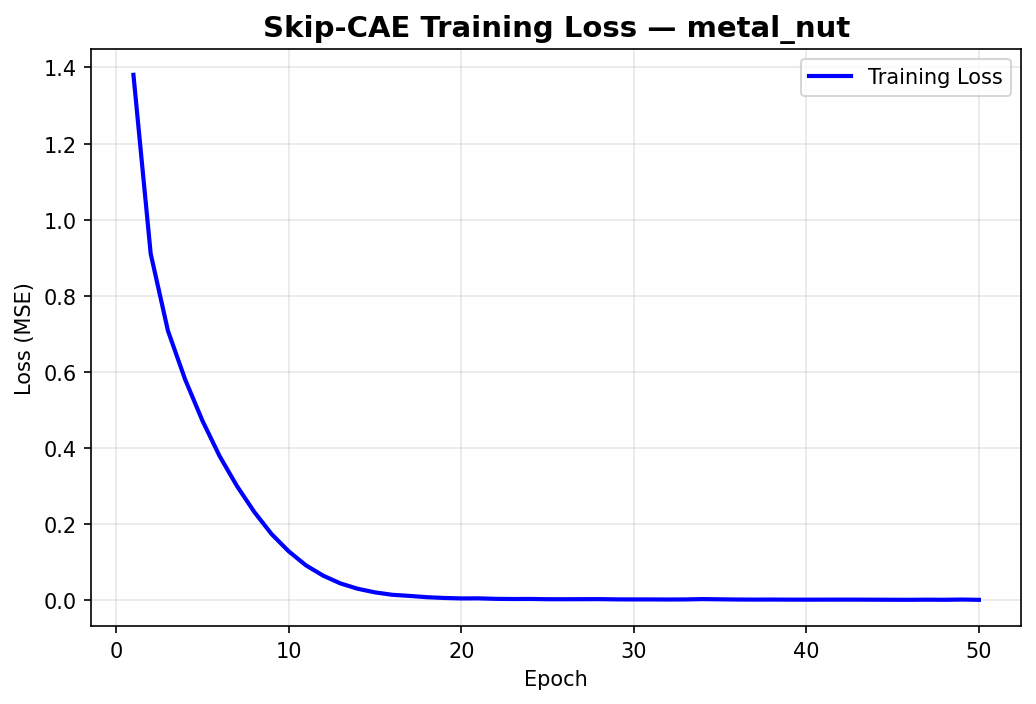



🖼️ skip_cae_metal_nut_roc.png


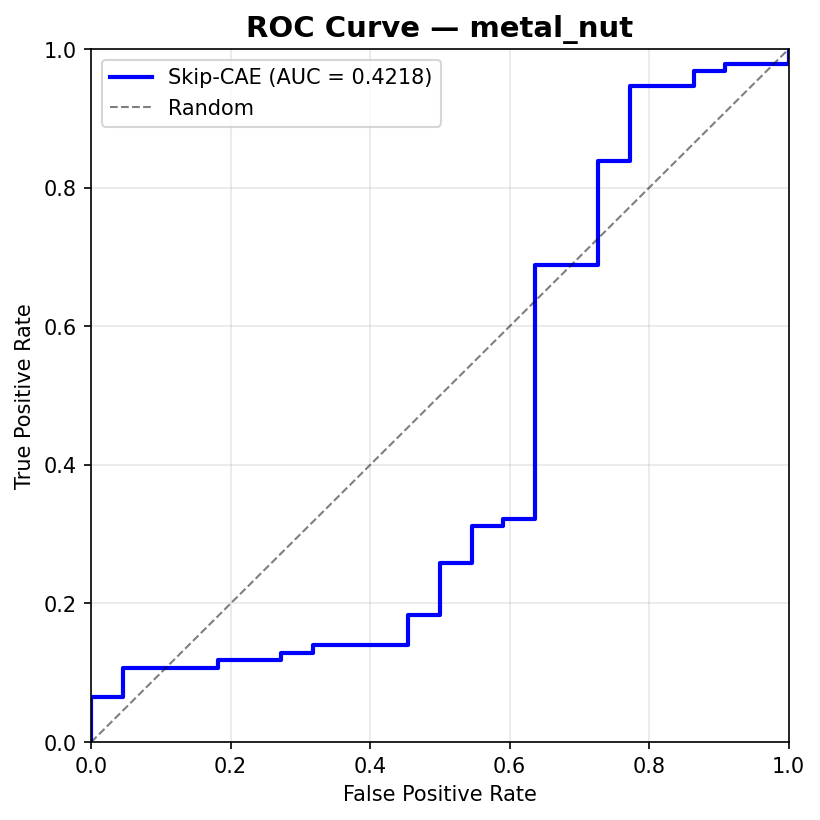



🖼️ skip_cae_pill_loss.png


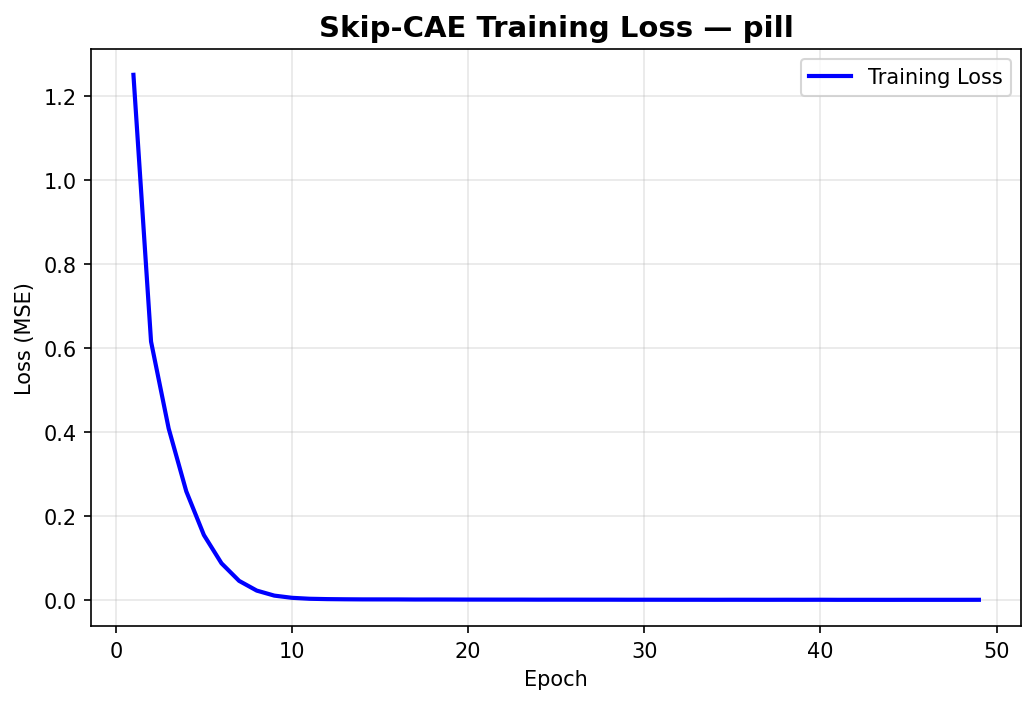



🖼️ skip_cae_pill_roc.png


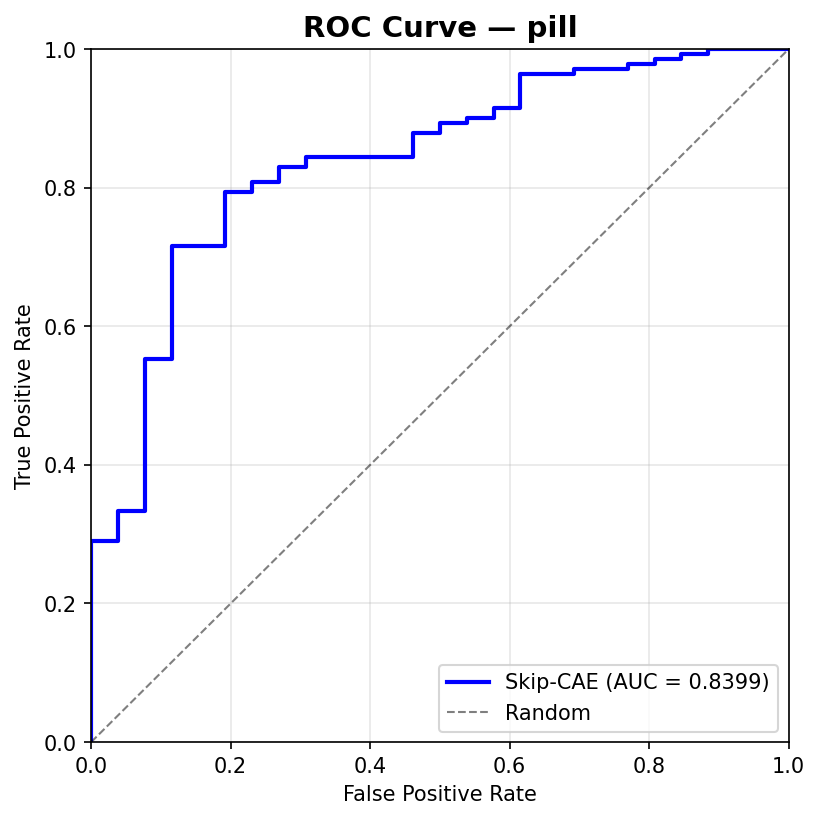



🖼️ skip_cae_screw_loss.png


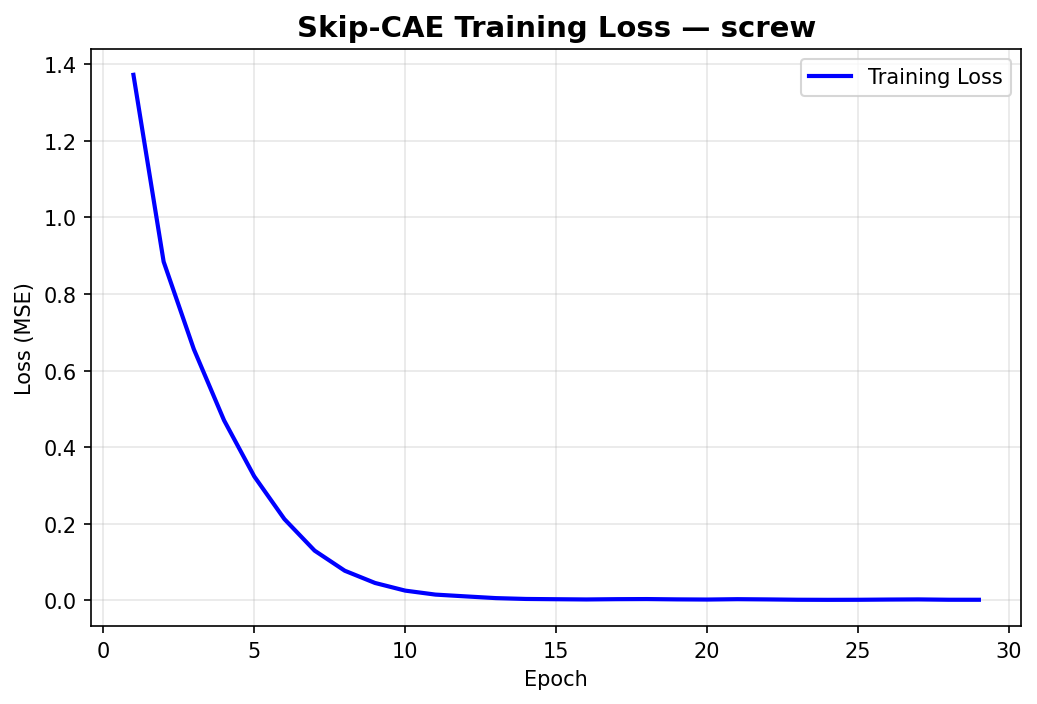



🖼️ skip_cae_screw_roc.png


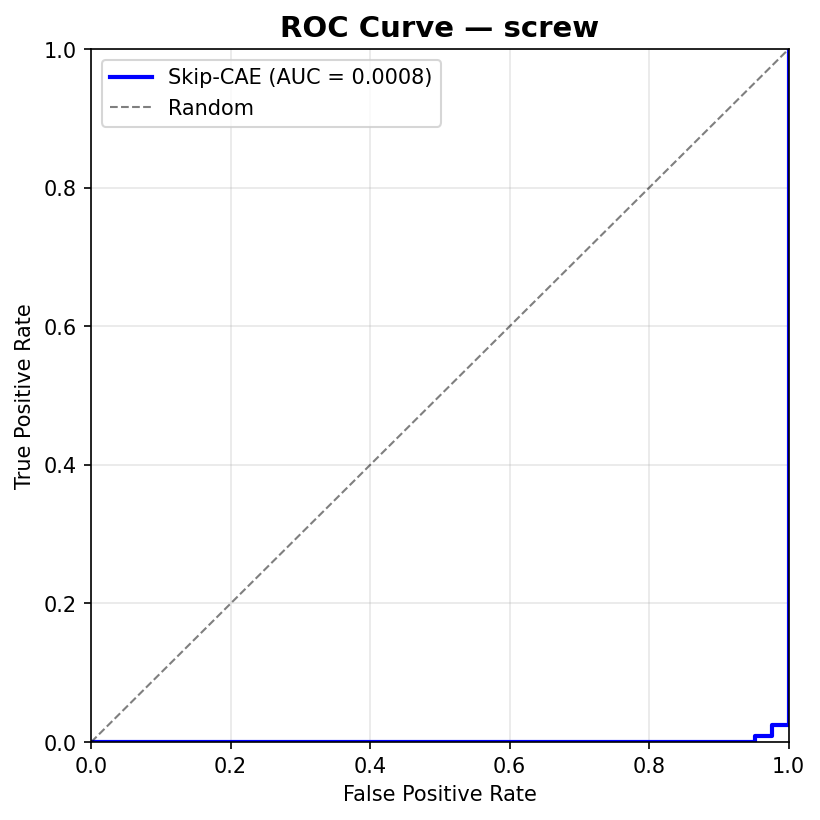



🖼️ skip_cae_tile_loss.png


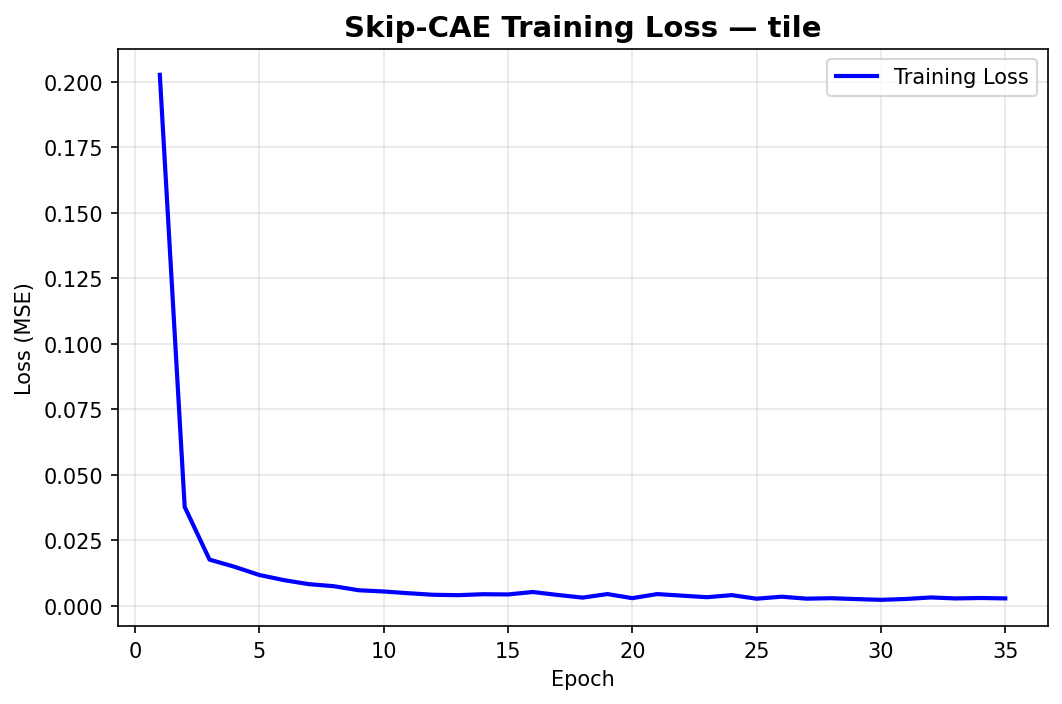



🖼️ skip_cae_tile_roc.png


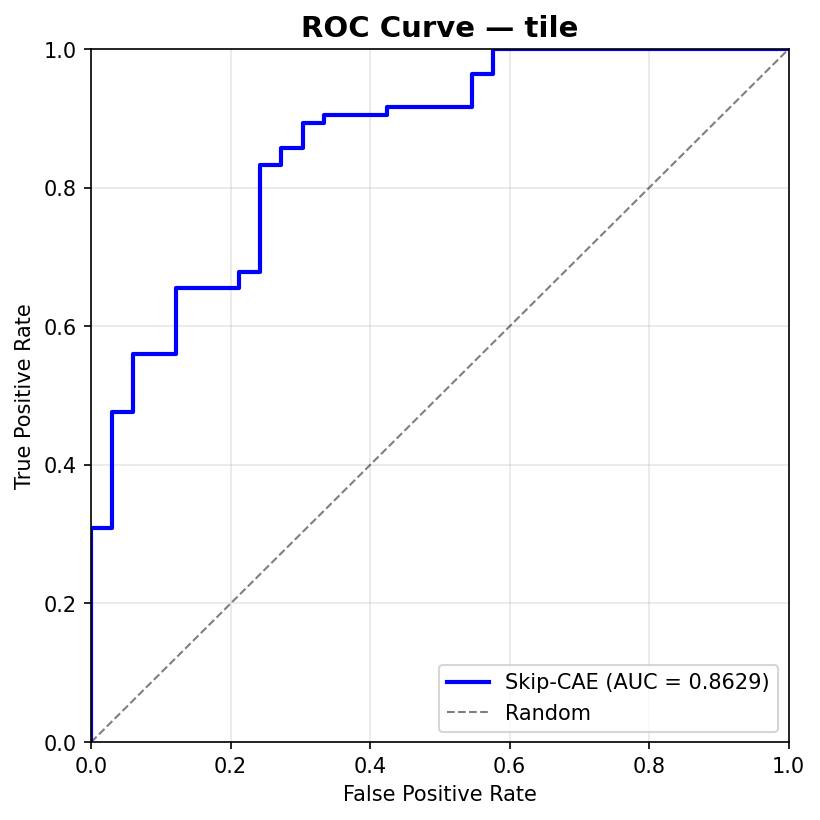



🖼️ skip_cae_toothbrush_loss.png


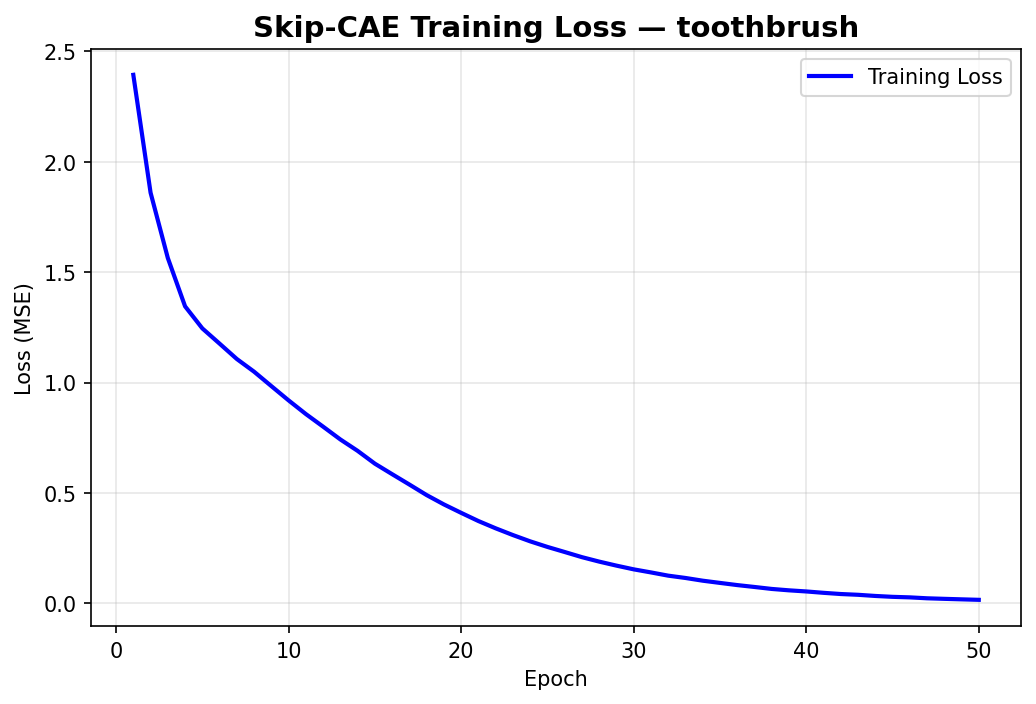



🖼️ skip_cae_toothbrush_roc.png


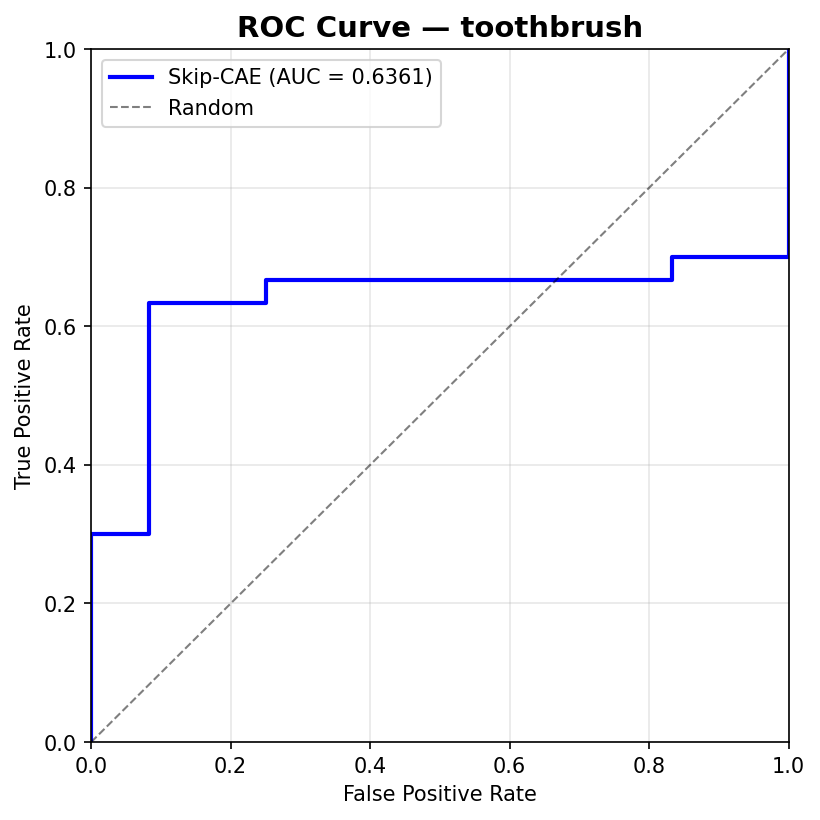



🖼️ skip_cae_transistor_loss.png


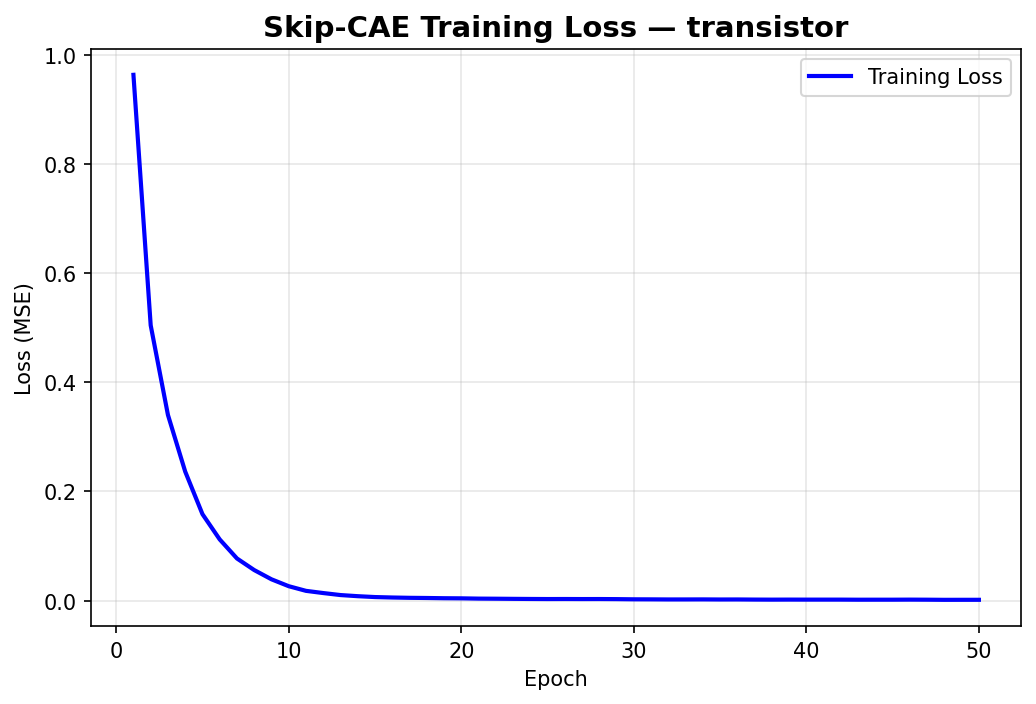



🖼️ skip_cae_transistor_roc.png


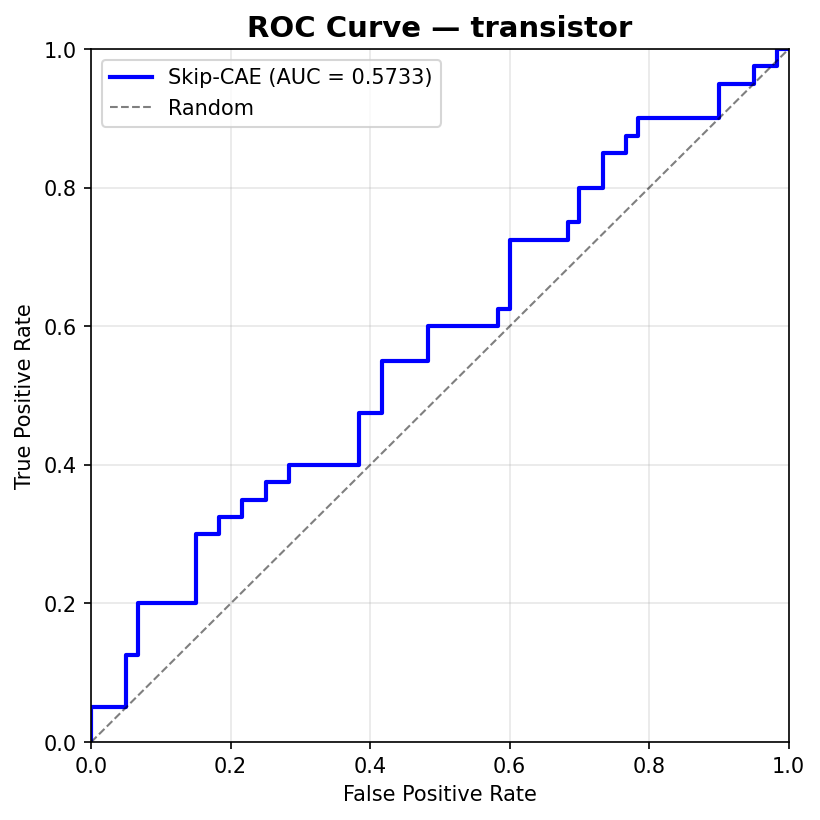



🖼️ skip_cae_wood_loss.png


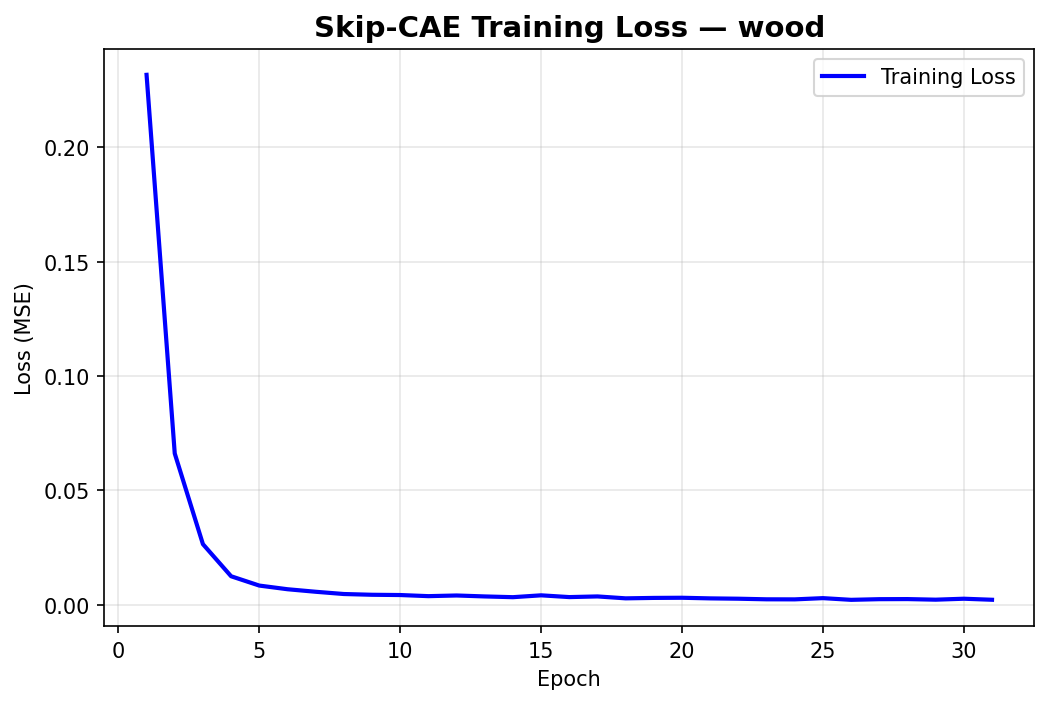



🖼️ skip_cae_wood_roc.png


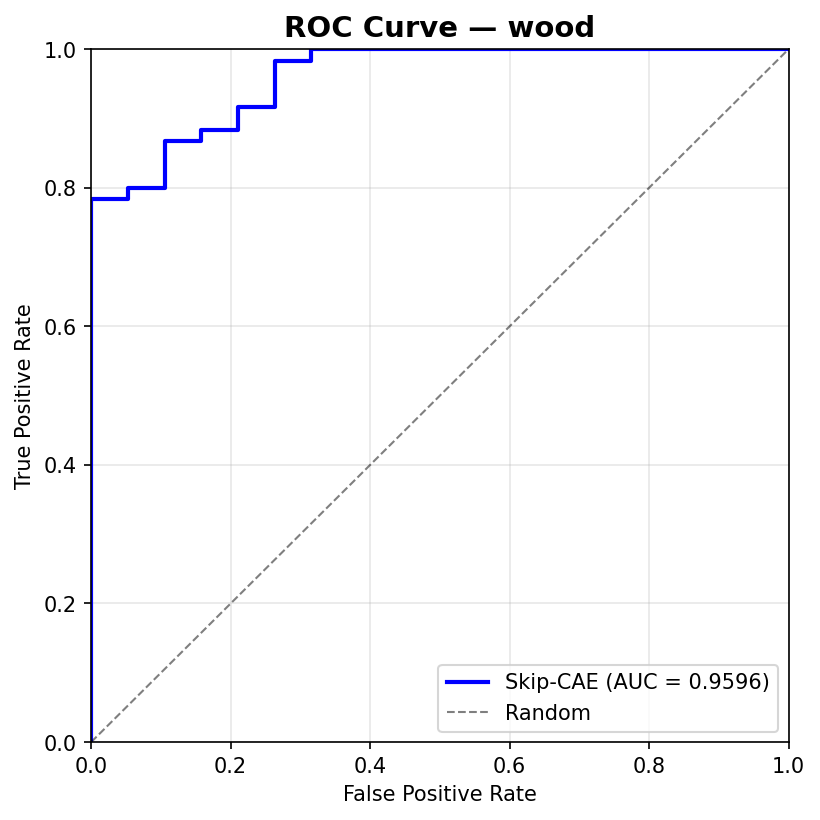



🖼️ skip_cae_zipper_loss.png


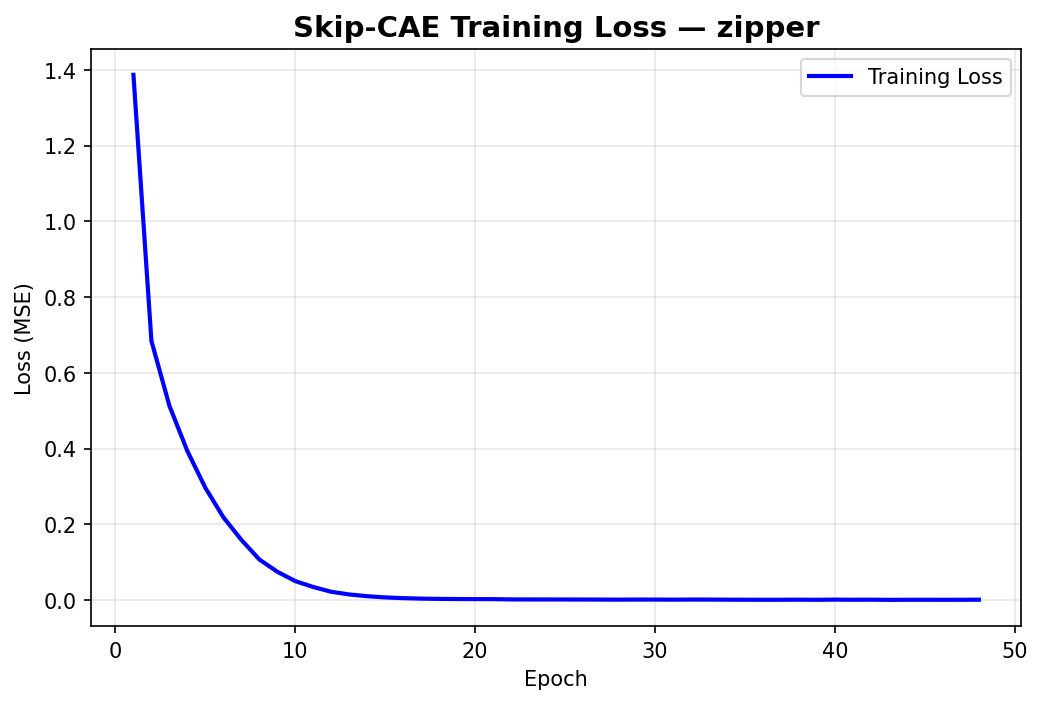



🖼️ skip_cae_zipper_roc.png


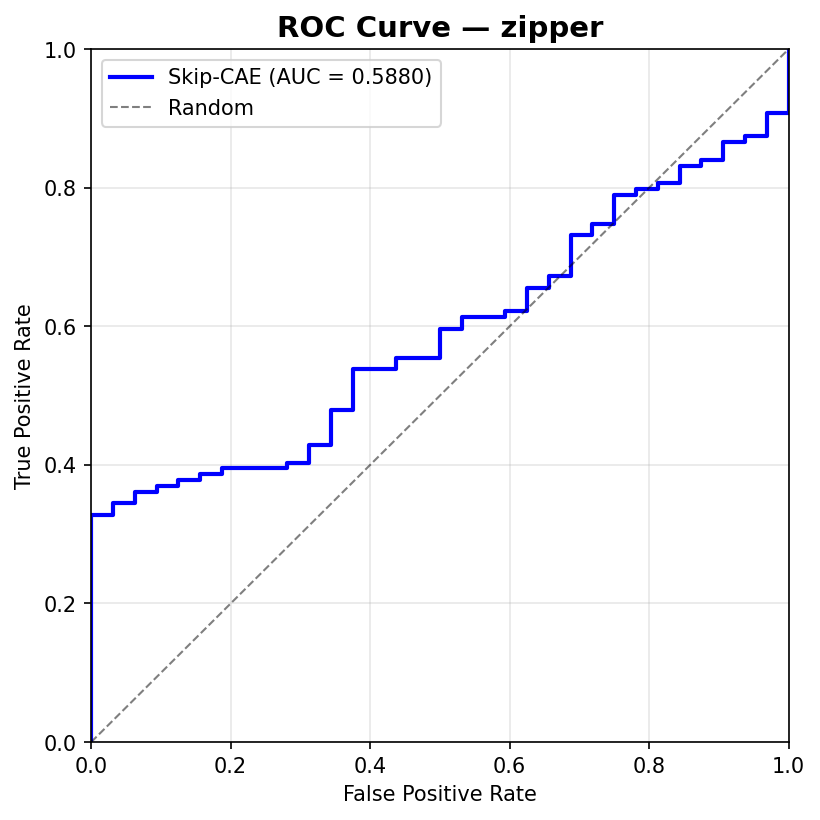

In [11]:
from IPython.display import Image, display
from pathlib import Path

# Point to your figures directory
fig_dir = Path('/kaggle/working/figures')

# Find all PNG files and sort them alphabetically
image_files = sorted(fig_dir.glob('*.png'))

if not image_files:
    print("No images found in /kaggle/working/figures")
else:
    print(f"Found {len(image_files)} images. Displaying now...\n")
    for img_path in image_files:
        print(f"{'='*40}\n🖼️ {img_path.name}\n{'='*40}")
        display(Image(filename=str(img_path)))
        print("\n") # Add a little breathing room between images

In [12]:
import shutil

# This will zip everything inside /kaggle/working/ into a file named 'skip_cae_results.zip'
shutil.make_archive('skip_cae_results', 'zip', '/kaggle/working')

print("Zipping complete! Check your output folder.")

Zipping complete! Check your output folder.
